In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt
import scanpy as sc
import pandas as pd
import seaborn as sns
import jax
import jax.numpy as jnp
cpu = jax.devices('cpu')[0]
jax.config.update('jax_default_device', cpu)
from gstatot import utils
from matplotlib.legend_handler import HandlerTuple

sns.set_context("paper", font_scale=1.5)
sns.set_theme(style="ticks")

# The preprocessed data can be generated by running the scripts in '../extra/data_preprocessing/hematopoiesis/' 
# or downloaded from the archive at https://doi.org/10.5281/zenodo.20723235. The full fitted integrated hemo data sets
# are available in full_fitted_integrated_hemo_data_sets.tar.gz, while the sparsely fitted adatas used in this notebook are 
# available in sparsely_fitted_integrated_hemo_data_sets.tar.gz.

data_dir = '../data/hemo_data'


In [2]:
def AP(retrieved_genes, gT_genes):
    P = []
    if len(retrieved_genes) == 0:
        return 0.0
    for k in range(1, len(retrieved_genes) + 1):
        precision_at_k = len(set(retrieved_genes[:k]).intersection(set(gT_genes))) / k
        if retrieved_genes[k-1] in gT_genes:
            P.append(precision_at_k)
    return sum(P) / len(gT_genes)

In [3]:
postnatal_adata = sc.read_h5ad(f'{data_dir}/postnatal_integrated_StatOT_fitted.h5ad')
prenatal_adata = sc.read_h5ad(f'{data_dir}/prenatal_integrated_StatOT_fitted.h5ad')

In [4]:
import gc
from gstatot import gene_selection
compute_baseline_DE = True

for n in [100, 300]:

    prenatal_down_sampled = sc.read_h5ad(f'{data_dir}/prenatal_downsampled_gStatOT_fitted_n={n}.h5ad')
    postnatal_down_sampled = sc.read_h5ad(f'{data_dir}/postnatal_downsampled_gStatOT_fitted_n={n}.h5ad')
    prenatal_down_sampled_sot = sc.read_h5ad(f'{data_dir}/prenatal_downsampled_StatOT_fitted_n={n}.h5ad')
    postnatal_down_sampled_sot = sc.read_h5ad(f'{data_dir}/postnatal_downsampled_StatOT_fitted_n={n}.h5ad')

    # driver gene identification the correlation b/w fate probability and gene expression
    os.makedirs(f'{data_dir}/../gene_lists/', exist_ok=True)

    adata_keys  = {'time_key': 'age_wks',
                   'cell_type_key': 'cell_type'}

    fate_names = prenatal_adata.uns['terminal_lineages']
    
    pre_gSOT_dg_id = gene_selection(adata=prenatal_down_sampled, adata_keys=adata_keys, full_supp=True, fate_names=fate_names)
    pre_gSOT_dg_id.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)
    
   
    pre_SOT_dg_id = gene_selection(adata=prenatal_down_sampled_sot, adata_keys=adata_keys, full_supp=False, fate_names=fate_names)
    pre_SOT_dg_id.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)
    
   
    pre_GT_dg_id = gene_selection(adata=prenatal_adata, adata_keys=adata_keys, full_supp=False, fate_names=fate_names)
    pre_GT_dg_id.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)

    adata_keys  = {'time_key': 'age_yrs',
                  'cell_type_key': 'cell_type'}

    post_gSOT_dg_id = gene_selection(adata=postnatal_down_sampled, adata_keys=adata_keys, full_supp=True, fate_names=fate_names)
    post_gSOT_dg_id.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)

    post_SOT_dg_id = gene_selection(adata=postnatal_down_sampled_sot, adata_keys=adata_keys, full_supp=False, fate_names=fate_names)
    post_SOT_dg_id.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)
    
       
    post_GT_dg_id = gene_selection(adata=postnatal_adata, adata_keys=adata_keys, full_supp=False, fate_names=fate_names)
    post_GT_dg_id.get_fp_expression_corr(label_key=adata_keys['cell_type_key'], fate_names=fate_names)
    
    
    pre_dg_id_list = [pre_gSOT_dg_id, pre_SOT_dg_id]
    post_dg_id_list = [post_gSOT_dg_id, post_SOT_dg_id]
    
    num_genes = [5, 10, 25, 50]
    n_samples = 1000
    
    res = {'Method':[], 'Age':[], 'Fate':[], 'Top genes':[], 'AP':[]}
    from tqdm import tqdm
    for n_genes in num_genes:
    
        for dg_id in pre_dg_id_list + post_dg_id_list:
            _ = dg_id.rank_genes(n_top_genes=n_samples) 
    
        pre_GT_dg_id.rank_genes(n_top_genes=n_genes) # only take top n_genes from the ground truth as relevant
        post_GT_dg_id.rank_genes(n_top_genes=n_genes)
    
    
        for fate in tqdm(fate_names):
            for i, age in enumerate(post_GT_dg_id.times):
            
                GT_genes = post_GT_dg_id.cell_type_top_genes[fate]
                gSOT_genes = post_gSOT_dg_id.cell_type_top_genes[fate][age].index.tolist()
                SOT_genes = post_SOT_dg_id.cell_type_top_genes[fate][age].index.tolist()
                GT_genes_a = GT_genes[age].index.tolist()
                GT_genes_am1 = GT_genes[post_GT_dg_id.times[i-1]].index.tolist() if i > 0 else []
                GT_genes_ap1 = GT_genes[post_GT_dg_id.times[i+1]].index.tolist() if i < len(post_GT_dg_id.times)-1 else []
    
                ap_gSOT = AP(gSOT_genes, GT_genes_a)
                ap_SOT = AP(SOT_genes, GT_genes_a)
                if i == 0:
                    ap_GT = AP(GT_genes_ap1, GT_genes_a)
                elif i == len(post_GT_dg_id.times)-1:
                    ap_GT = AP(GT_genes_am1, GT_genes_a)
                else:
                    ap_GT = 0.5 * (AP(GT_genes_am1, GT_genes_a) + AP(GT_genes_ap1, GT_genes_a)) 
    
    
                res['Method'].extend(['gStatOT', 'StatOT', 'GT-TC'])
                res['Age'].extend([str(age) + ' (yrs)']*3)
                res['Fate'].extend([fate]*3)
                res['Top genes'].extend([n_genes]*3)
                res['AP'].extend([ap_gSOT, ap_SOT, ap_GT])
    
            for i, age in enumerate(pre_GT_dg_id.times):
            
                if fate in pre_gSOT_dg_id.cell_type_top_genes.keys():
                    gSOT_genes = pre_gSOT_dg_id.cell_type_top_genes[fate][age].index.tolist()
                    SOT_genes = pre_SOT_dg_id.cell_type_top_genes[fate][age].index.tolist()
                else:
                    gSOT_genes = []
                    SOT_genes = []
    
    
                GT_genes = pre_GT_dg_id.cell_type_top_genes[fate]
                GT_genes_a = GT_genes[age].index.tolist()
                GT_genes_am1 = GT_genes[pre_GT_dg_id.times[i-1]].index.tolist() if i > 0 else []
                GT_genes_ap1 = GT_genes[pre_GT_dg_id.times[i+1]].index.tolist() if i < len(pre_GT_dg_id.times)-1 else []
    
                ap_gSOT = AP(gSOT_genes, GT_genes_a)
                ap_SOT = AP(SOT_genes, GT_genes_a)
                if i == 0:
                    ap_GT = AP(GT_genes_ap1, GT_genes_a)
                elif i == len(pre_GT_dg_id.times)-1:
                    ap_GT = AP(GT_genes_am1, GT_genes_a)
                else:
                    ap_GT = 0.5 * (AP(GT_genes_am1, GT_genes_a) + AP(GT_genes_ap1, GT_genes_a)) 
    
                res['Method'].extend(['gStatOT', 'StatOT', 'GT-TC'])
                res['Age'].extend([str(age) + ' (wks)']*3)
                res['Fate'].extend([fate]*3)
                res['Top genes'].extend([n_genes]*3)
                res['AP'].extend([ap_gSOT, ap_SOT, ap_GT])
    
    del postnatal_down_sampled.obsp
    gc.collect()
    if compute_baseline_DE:
        for age in post_GT_dg_id.times:
            # DE baseline
            age_adata = postnatal_down_sampled[(postnatal_down_sampled.obs['age_yrs'] == age)].copy()
            for fate in fate_names:
                if age_adata[age_adata.obs['cell_type']==fate].shape[0] <= 1: # cannot do DE with only one cell in a cluster
                    age_adata = age_adata[age_adata.obs['cell_type'] != fate].copy()

            sc.tl.rank_genes_groups(age_adata, groupby='cell_type', reference='rest', method='wilcoxon')

            for n_genes in num_genes:
                post_GT_dg_id.rank_genes(n_top_genes=n_genes)
                for fate_ in fate_names:
                    if fate_ in age_adata.uns['rank_genes_groups']['names'].dtype.names:
                        de_genes = age_adata.uns['rank_genes_groups']['names'][fate_][:n_samples].tolist()
                        GT_genes = post_GT_dg_id.cell_type_top_genes[fate_][age].index.tolist()
                        res['Method'].append('DE baseline')
                        res['Age'].append(str(age) + ' (yrs)')
                        res['Fate'].append(fate_)
                        res['Top genes'].append(n_genes)
                        res['AP'].append(AP(de_genes, GT_genes))
            del age_adata
            gc.collect()

        for age in pre_GT_dg_id.times:
            # DE baseline
            age_adata = prenatal_down_sampled[(prenatal_down_sampled.obs['age_wks'] == age)].copy()

            for fate in fate_names:
                if age_adata[age_adata.obs['cell_type']==fate].shape[0] <= 1: # cannot do DE with only one cell in a cluster
                    age_adata = age_adata[age_adata.obs['cell_type'] != fate].copy()

            sc.tl.rank_genes_groups(age_adata, groupby='cell_type', reference='rest', method='wilcoxon')

            for n_genes in num_genes:
                pre_GT_dg_id.rank_genes(n_top_genes=n_genes) 
                for fate_ in fate_names:
                    if fate_ in age_adata.uns['rank_genes_groups']['names'].dtype.names:
                        de_genes = age_adata.uns['rank_genes_groups']['names'][fate_][:n_samples].tolist()
                        GT_genes = pre_GT_dg_id.cell_type_top_genes[fate_][age].index.tolist()
                        res['Method'].append('DE baseline')
                        res['Age'].append(str(age) + ' (wks)')
                        res['Fate'].append(fate_)
                        res['Top genes'].append(n_genes)
                        res['AP'].append(AP(de_genes, GT_genes))
            del age_adata
            gc.collect()

    
    
    AP_df = pd.DataFrame(res)
    AP_df.to_csv(f'{data_dir}/../gene_lists/driver_gene_AP_results_n={n}.csv', index=False)


100%|██████████| 6/6 [00:01<00:00,  4.01it/s]


## Figure 7

In [5]:
n = 100
prenatal_downsampled_gsot = sc.read_h5ad(f'{data_dir}/prenatal_downsampled_gStatOT_fitted_n={n}.h5ad')
postnatal_downsampled_gsot = sc.read_h5ad(f'{data_dir}/postnatal_downsampled_gStatOT_fitted_n={n}.h5ad')
prenatal_downsampled_sot = sc.read_h5ad(f'{data_dir}/prenatal_downsampled_StatOT_fitted_n={n}.h5ad')
postnatal_downsampled_sot = sc.read_h5ad(f'{data_dir}/postnatal_downsampled_StatOT_fitted_n={n}.h5ad')

In [6]:
n = 300
prenatal_downsampled_gsot_n300 = sc.read_h5ad(f'{data_dir}/prenatal_downsampled_gStatOT_fitted_n={n}.h5ad')
postnatal_downsampled_gsot_n300 = sc.read_h5ad(f'{data_dir}/postnatal_downsampled_gStatOT_fitted_n={n}.h5ad')
prenatal_downsampled_sot_n300 = sc.read_h5ad(f'{data_dir}/prenatal_downsampled_StatOT_fitted_n={n}.h5ad')
postnatal_downsampled_sot_n300 = sc.read_h5ad(f'{data_dir}/postnatal_downsampled_StatOT_fitted_n={n}.h5ad')

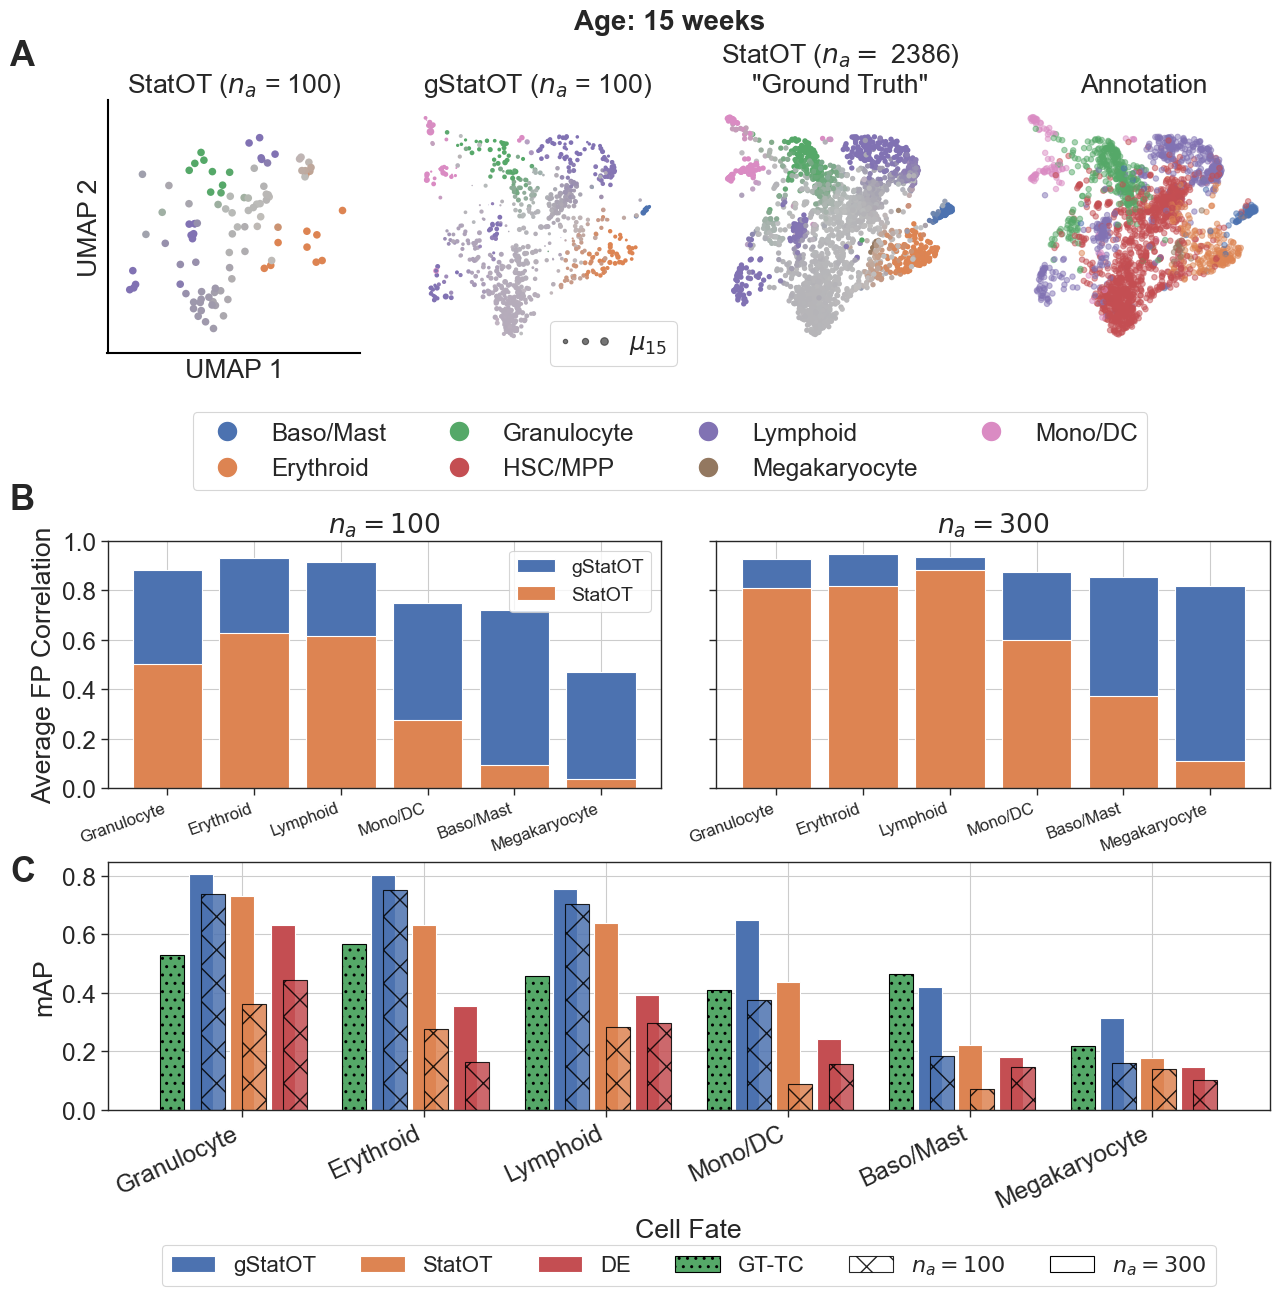

In [7]:

AP_df_n300 = pd.read_csv(f'{data_dir}/../gene_lists/driver_gene_AP_results_n=300.csv')
AP_df_n100 = pd.read_csv(f'{data_dir}/../gene_lists/driver_gene_AP_results_n=100.csv')

sns.set_style("ticks")
sns.set_context('paper', font_scale=2)
width = 1.25
gap = 0.25
n_genes = 10
x = np.arange(6) * 9.5
fate_names = np.array(['Granulocyte', 'Erythroid', 'Lymphoid', 'Mono/DC', 'Baso/Mast','Megakaryocyte'])

colors = sns.color_palette("deep", 4)
colors_dict = {'gStatOT':colors[0], 'StatOT':colors[1], 'DE baseline':colors[3], 'GT-TC':colors[2]}

fig = plt.figure(figsize=(15, 12))
subfigs = fig.subfigures(nrows=3, ncols=1, height_ratios=[1.3, 0.75, 0.75])

ax = subfigs[2].add_subplot(111)

metric = 'AP'
scores_df_ = AP_df_n100[AP_df_n100['Top genes'] == n_genes]
scores_df_500 = AP_df_n300[AP_df_n300['Top genes'] == n_genes]

ax.bar(x = x - (width + width/2) - gap, height=scores_df_500[scores_df_500['Method'].str.contains('gStatOT')].groupby('Fate')[metric].mean()[fate_names], 
       width=width, 
       label='', alpha=1, color=colors_dict['gStatOT'])
ax.bar(x = x - width - gap, height=scores_df_[scores_df_['Method'].str.contains('gStatOT')].groupby('Fate')[metric].mean()[fate_names], 
       width=width, label='', alpha=0.85, color=colors_dict['gStatOT'], hatch='x', edgecolor='black')

ax.bar(x = x, height=scores_df_500[~(scores_df_500['Method'].str.contains('gStatOT') | scores_df_500['Method'].str.contains('DE baseline') | scores_df_500['Method'].str.contains('GT-TC'))].groupby('Fate')[metric].mean()[fate_names], 
       width=width, label='', alpha=1, color=colors_dict['StatOT'])
ax.bar(x = x+width/2 , height=scores_df_[~(scores_df_['Method'].str.contains('gStatOT') | scores_df_['Method'].str.contains('DE baseline') | scores_df_['Method'].str.contains('GT-TC'))].groupby('Fate')[metric].mean()[fate_names], 
       width=width, label='', alpha=0.85, color=colors_dict['StatOT'], hatch='x', edgecolor='black')

ax.bar(x = x + width + width/2 + gap, height=scores_df_500[scores_df_500['Method'].str.contains('DE baseline')].groupby('Fate')[metric].mean()[fate_names], 
       width=width, label='', alpha=1, color=colors_dict['DE baseline'])
ax.bar(x = x + width + width + gap, height=scores_df_[scores_df_['Method'].str.contains('DE baseline')].groupby('Fate')[metric].mean()[fate_names], 
       width=width, label='', alpha=0.85, color=colors_dict['DE baseline'], hatch='x', edgecolor='black')

ax.bar(x=x - 2*gap - 2.5*width, height=scores_df_500[scores_df_500['Method'].str.contains('GT-TC')].groupby('Fate')[metric].mean()[fate_names], 
       width=width, color=colors_dict['GT-TC'], label='', hatch='..', edgecolor='black', alpha=1)

ax.bar(x=0, height=0, width=0, label=f'gStatOT', color=colors_dict['gStatOT'], alpha=1)
ax.bar(x=0, height=0, width=0, label=f'StatOT', color=colors_dict['StatOT'], alpha=1)
ax.bar(x=0, height=0, width=0, label=f'DE', color=colors_dict['DE baseline'], alpha=1)
ax.bar(x=0, height=0, width=0, label=f'GT-TC', color=colors_dict['GT-TC'], alpha=1, hatch='..', edgecolor='black')

ax.bar(x=0, height=0, width=0, label=r'$n_a = 100$', color='white', alpha=0.85, hatch='x', edgecolor='black')
ax.bar(x=0, height=0, width=0, label=r'$n_a = 300$', color='white', alpha=1, edgecolor='black')


ax.set_xticks(x, labels=fate_names, rotation=25, ha='right')
ax.grid()

ax.set_ylabel('mAP')
ax.set_xlabel('Cell Fate')

ax.legend(bbox_to_anchor=(0.5, -0.5), loc='upper center', fontsize=16, ncol=6)

cell_colors = prenatal_adata.uns['cell_type_colors']
lin_col_map = {lin: cell_colors[i] for i, lin in enumerate(prenatal_adata.obs['cell_type'].cat.categories)}

x_lim = (prenatal_adata.obsm['X_umap'][:, 0].min() - 1, prenatal_adata.obsm['X_umap'][:, 0].max() + 1)
y_lim = (prenatal_adata.obsm['X_umap'][:, 1].min() - 1, prenatal_adata.obsm['X_umap'][:, 1].max() + 1)


############ UMAPS

age = 15.0 
max_s = 30

axes = subfigs[0].subplots(1,4, sharex=True, sharey=True)
for ax in axes:
    ax.set_box_aspect(1)
ax1, ax2, ax3, ax4 = axes
utils.plot_fp(prenatal_downsampled_sot, age=age, time_key='age_wks', embed_key='X_umap', label_key='cell_type', lineages=prenatal_adata.uns['terminal_lineages'], 
              lineage_color_map=lin_col_map, full_supp=False, ax=ax1, max_s=max_s, x_lim=x_lim, y_lim=y_lim)
utils.plot_fp(prenatal_downsampled_gsot, age=age, time_key='age_wks', embed_key='X_umap', label_key='cell_type', lineages=prenatal_adata.uns['terminal_lineages'], 
              lineage_color_map=lin_col_map, full_supp=True, ax=ax2, max_s=max_s, x_lim=x_lim, y_lim=y_lim)

scatter = ax2.collections[0]
handles, _ = scatter.legend_elements(prop="sizes", num=3, alpha=0.6)
ax2.legend(
    [tuple(handles)],            
    [r'$\mu_{15}$'],      
    handler_map={tuple: HandlerTuple(ndivide=None)}, 
    loc="lower right",
    bbox_to_anchor=(1.1, -0.1)
)
utils.plot_fp(prenatal_adata, age=age, time_key='age_wks', embed_key='X_umap', label_key='cell_type', lineages=prenatal_adata.uns['terminal_lineages'], 
              lineage_color_map=lin_col_map, full_supp=False, ax=ax3, max_s=max_s/2, x_lim=x_lim, y_lim=y_lim)

ax4.axis('off')
X_umap = prenatal_adata.obsm['X_umap'][prenatal_adata.obs['age_wks'] == age]
cell_colors = prenatal_adata.obs['cell_type'].map(lin_col_map)[prenatal_adata.obs['age_wks'] == age]
ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=cell_colors, s=max_s/2, edgecolor=None, alpha=0.5)
ax4.set_title("Annotation")
ax4.set_xlim(x_lim)
ax4.set_ylim(y_lim)

handles = [plt.Line2D([0], [0], marker='o', color='w', label=lin, markerfacecolor=col, markersize=5) for lin, col in lin_col_map.items()]
subfigs[0].legend(
    handles=handles,
    loc="lower center", 
    bbox_to_anchor=(0.5, 0.0), # Positions it exactly at the bottom edge
    markerscale=3,
    ncol=4
)

fig.text(0.50, 0.93, f"Age: {int(age)} weeks", ha='center', fontsize=20, fontweight='bold')

axes[0].set_title(r'StatOT ($n_a$ = {})'.format(100))
axes[1].set_title(r'gStatOT ($n_a$ = {})'.format(100))
axes[2].set_title(r'StatOT ($n_a =$ {})'.format(prenatal_adata[prenatal_adata.obs['age_wks'] == age].shape[0]) + '\n"Ground Truth"')

#plt.subplots_adjust(top=0.90, hspace=0.4)

for c in range(3):
    ax = axes[c]
    
    if c == 0:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_linewidth(1.5)
        ax.spines['bottom'].set_linewidth(1.5)
        
        ax.xaxis.set_ticks_position('bottom')
        ax.yaxis.set_ticks_position('left')

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        
    else:
        ax.axis('off')

# Label top subplot and bottom subplot 
fig.text(0.06, 0.90, 'A', fontsize=25, fontweight='bold')
fig.text(0.06, 0.53, 'B', fontsize=25, fontweight='bold')
fig.text(0.06, 0.22, 'C', fontsize=25, fontweight='bold')

################ Correlation b/w fate probabilities

axes = subfigs[1].subplots(1, 2, sharex=True, sharey=True, gridspec_kw={'wspace': 0.1})

pre_SOT_corrs = np.nan_to_num(prenatal_downsampled_sot.uns['FP_lin_corr'])
pre_gSOT_corrs = np.nan_to_num(prenatal_downsampled_gsot.uns['FP_lin_corr'])
post_SOT_corrs = np.nan_to_num(postnatal_downsampled_sot.uns['FP_lin_corr'])
post_gSOT_corrs = np.nan_to_num(postnatal_downsampled_gsot.uns['FP_lin_corr'])

SOT_corrs = np.concatenate([pre_SOT_corrs, post_SOT_corrs], axis=0)
gSOT_corrs = np.concatenate([pre_gSOT_corrs, post_gSOT_corrs], axis=0)
SOT_avg_corr = SOT_corrs.mean(axis=0)
gSOT_avg_corr = gSOT_corrs.mean(axis=0)

celltypes = prenatal_adata.uns['terminal_lineages']
# order cell types as in fate_names
celltypes_ind = np.array([np.where(celltypes == fate)[0][0] for fate in fate_names])
celltypes = celltypes[celltypes_ind]
axes[0].set_ylim(0, 1)
axes[0].bar(celltypes, gSOT_avg_corr[celltypes_ind], label='gStatOT')
axes[0].bar(celltypes, SOT_avg_corr[celltypes_ind], label='StatOT')
axes[0].set_ylabel('Average FP Correlation')
axes[0].set_title(r'$n_a = {}$'.format(100))
axes[0].set_xticks(range(len(celltypes)))
axes[0].set_xticklabels(celltypes, rotation=20, ha='right', fontsize=12)
axes[0].grid()
axes[0].legend(fontsize=14)

pre_SOT_corrs = np.nan_to_num(prenatal_downsampled_sot_n300.uns['FP_lin_corr'])
pre_gSOT_corrs = np.nan_to_num(prenatal_downsampled_gsot_n300.uns['FP_lin_corr'])
post_SOT_corrs = np.nan_to_num(postnatal_downsampled_sot_n300.uns['FP_lin_corr'])
post_gSOT_corrs = np.nan_to_num(postnatal_downsampled_gsot_n300.uns['FP_lin_corr'])

SOT_corrs = np.concatenate([pre_SOT_corrs, post_SOT_corrs], axis=0)
gSOT_corrs = np.concatenate([pre_gSOT_corrs, post_gSOT_corrs], axis=0)
SOT_avg_corr = SOT_corrs.mean(axis=0)
gSOT_avg_corr = gSOT_corrs.mean(axis=0)

celltypes = prenatal_adata.uns['terminal_lineages']
# order cell types as in fate_names
celltypes_ind = np.array([np.where(celltypes == fate)[0][0] for fate in fate_names])
celltypes = celltypes[celltypes_ind]
axes[1].set_ylim(0, 1)
axes[1].bar(celltypes, gSOT_avg_corr[celltypes_ind], label='gStatOT')
axes[1].bar(celltypes, SOT_avg_corr[celltypes_ind], label='StatOT')
axes[1].set_title(r'$n_a = {}$'.format(300))
axes[1].set_xticks(range(len(celltypes)))
axes[1].set_xticklabels(celltypes, rotation=20, ha='right', fontsize=12)
axes[1].grid()

plt.savefig('./plots/figure_7.png', bbox_inches='tight', dpi=350)
plt.show()



#  Flow fields for SI

In [8]:
from scipy.interpolate import griddata
def plot_streams(X_umap, vecs, ax, density=1, alpha=1.0, linewidth=0.5):

    grid_x, grid_y = np.meshgrid(
        np.linspace(X_umap[:, 0].min(), X_umap[:, 0].max(), 100),
        np.linspace(X_umap[:, 1].min(), X_umap[:, 1].max(), 100)
    )

    grid_U = griddata(X_umap, vecs[:, 0], (grid_x, grid_y), method='linear')
    grid_V = griddata(X_umap, vecs[:, 1], (grid_x, grid_y), method='linear')

    ax.streamplot(
        grid_x[0, :], grid_y[:, 0], grid_U, grid_V,
        density=density,
        color='black',
        linewidth=linewidth,
        arrowsize=0.75,
    )

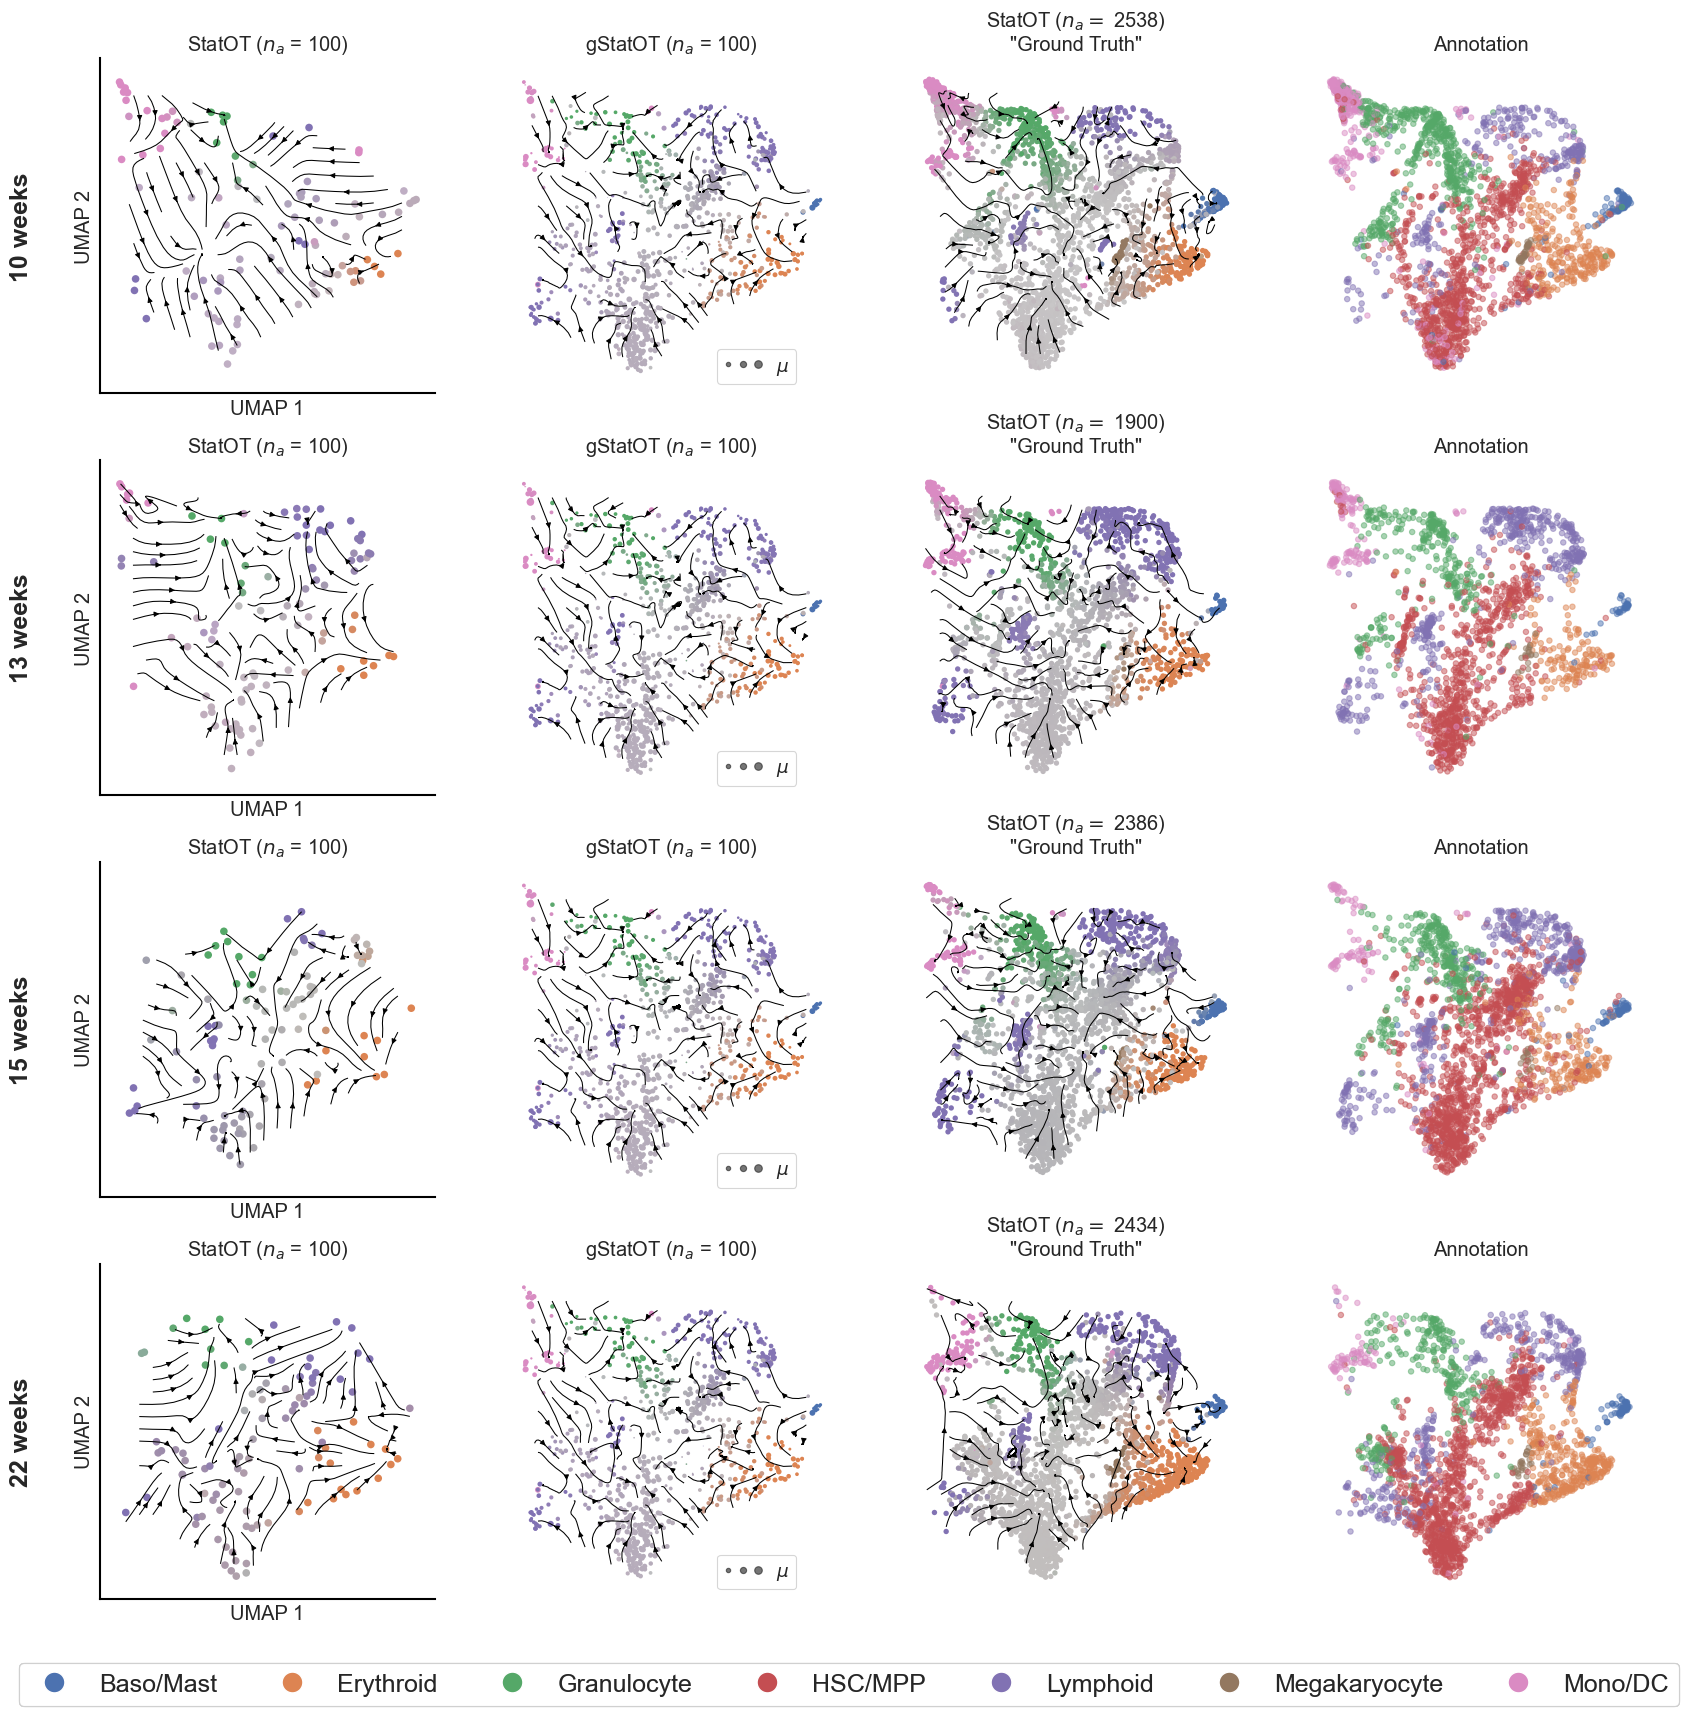

In [9]:
density = 0.75
alpha = 0.2
linewidth = 0.75
show_streams = True
sns.set_style("ticks")
sns.set_context('paper', font_scale=1.5)

max_s = 30
prenatal_ages = np.unique(prenatal_adata.obs['age_wks'])[::2]

fig, axes = plt.subplots(len(prenatal_ages), 4, figsize=(20, 5*len(prenatal_ages)), 
                         sharex=True, sharey=True)

for ax in axes.flatten():
    ax.set_box_aspect(1)

for i, age in enumerate(prenatal_ages):

    ax1, ax2, ax3, ax4 = axes[i]
    utils.plot_fp(prenatal_downsampled_sot, age=age, time_key='age_wks', embed_key='X_umap', label_key='cell_type', lineages=prenatal_adata.uns['terminal_lineages'], 
                  lineage_color_map=lin_col_map, full_supp=False, ax=ax1, max_s=max_s, x_lim=x_lim, y_lim=y_lim)
    utils.plot_fp(prenatal_downsampled_gsot, age=age, time_key='age_wks', embed_key='X_umap', label_key='cell_type', lineages=prenatal_adata.uns['terminal_lineages'], 
                  lineage_color_map=lin_col_map, full_supp=True, ax=ax2, max_s=max_s, x_lim=x_lim, y_lim=y_lim)

    scatter = ax2.collections[0]
    handles, _ = scatter.legend_elements(prop="sizes", num=3, alpha=0.6)
    ax2.legend(
        [tuple(handles)],            
        [rf'$\mu$'],      
        handler_map={tuple: HandlerTuple(ndivide=None)}, 
        loc="lower right",
        bbox_to_anchor=(0.9, 0.0)
    )
    utils.plot_fp(prenatal_adata, age=age, time_key='age_wks', embed_key='X_umap', label_key='cell_type', lineages=prenatal_adata.uns['terminal_lineages'], 
                  lineage_color_map=lin_col_map, full_supp=False, ax=ax3, max_s=max_s/2, x_lim=x_lim, y_lim=y_lim)

    ax4.axis('off')
    X_umap = prenatal_adata.obsm['X_umap'][prenatal_adata.obs['age_wks'] == age]
    cell_colors = prenatal_adata.obs['cell_type'].map(lin_col_map)[prenatal_adata.obs['age_wks'] == age]
    ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=cell_colors, s=max_s/2, edgecolor=None, alpha=0.5)
    ax4.set_title("Annotation")
    ax4.set_xlim(x_lim)
    ax4.set_ylim(y_lim)

    handles = [plt.Line2D([0], [0], marker='o', color='w', label=lin, markerfacecolor=col, markersize=5) for lin, col in lin_col_map.items()]
    fig.legend(
        handles=handles,
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.05), 
        markerscale=3,
        ncol=7,
        fontsize=18
    )

    pi = prenatal_downsampled_sot.uns['pi_' + str(age)]
    X_umap = prenatal_downsampled_sot.obsm['X_umap'][prenatal_downsampled_sot.obs['age_wks'] == age]
    sink_mask = prenatal_downsampled_sot[prenatal_downsampled_sot.obs['age_wks'] == age].obs['sink'] == 1

    P = utils.row_normalize(jnp.asarray(pi), sink_mask=jnp.asarray(sink_mask))
    vecs = P @ X_umap - X_umap

    if show_streams:
        plot_streams(X_umap, vecs, ax1 , density=density, alpha=alpha, linewidth=linewidth)
    
    pi = prenatal_downsampled_gsot.obsp['pi_' + str(age)]
    dist = pi.sum(0)
    P = utils.row_normalize(jnp.asarray(pi), sink_mask=jnp.asarray(prenatal_downsampled_gsot.obs['sink'] == 1))
    X_umap = prenatal_downsampled_gsot.obsm['X_umap']
    vecs = (P @ X_umap - X_umap) * dist.reshape(-1, 1)
    
    if show_streams:
        plot_streams(X_umap, vecs, ax2, density=density, alpha=alpha, linewidth=linewidth)
    
    pi = prenatal_adata.uns['pi_' + str(age)]
    sink_mask = prenatal_adata[prenatal_adata.obs['age_wks'] == age].obs['sink'] == 1
    P = utils.row_normalize(jnp.asarray(pi), sink_mask=jnp.asarray(sink_mask))
    X_umap = prenatal_adata.obsm['X_umap'][prenatal_adata.obs['age_wks'] == age]
    vecs = P @ X_umap - X_umap
    
    if show_streams:
        plot_streams(X_umap, vecs, ax3, density=density, alpha=alpha, linewidth=linewidth)

    ax1.annotate(f'{int(age)} weeks', 
             xy=(-0.2, 0.5), 
             xycoords='axes fraction',
             fontsize=18, 
             fontweight='bold',
             ha='right',    # Horizontal alignment
             va='center',   # Vertical alignment
             rotation=90)
    
    ax1.set_title(r'StatOT ($n_a$ = {})'.format(100))
    ax2.set_title(r'gStatOT ($n_a$ = {})'.format(100))
    ax3.set_title(r'StatOT ($n_a =$ {})'.format(prenatal_adata[prenatal_adata.obs['age_wks'] == age].shape[0]) + '\n"Ground Truth"')

    for j in range(3):
        ax = axes[i, j]

        if j == 0:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.spines['left'].set_color('black')
            ax.spines['bottom'].set_color('black')
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel("UMAP 1")
            ax.set_ylabel("UMAP 2")

        else:
            ax.axis('off')

fig.savefig('./plots/figure_7SI_prenatal_flowfields.png', bbox_inches='tight', dpi=350)
plt.show()


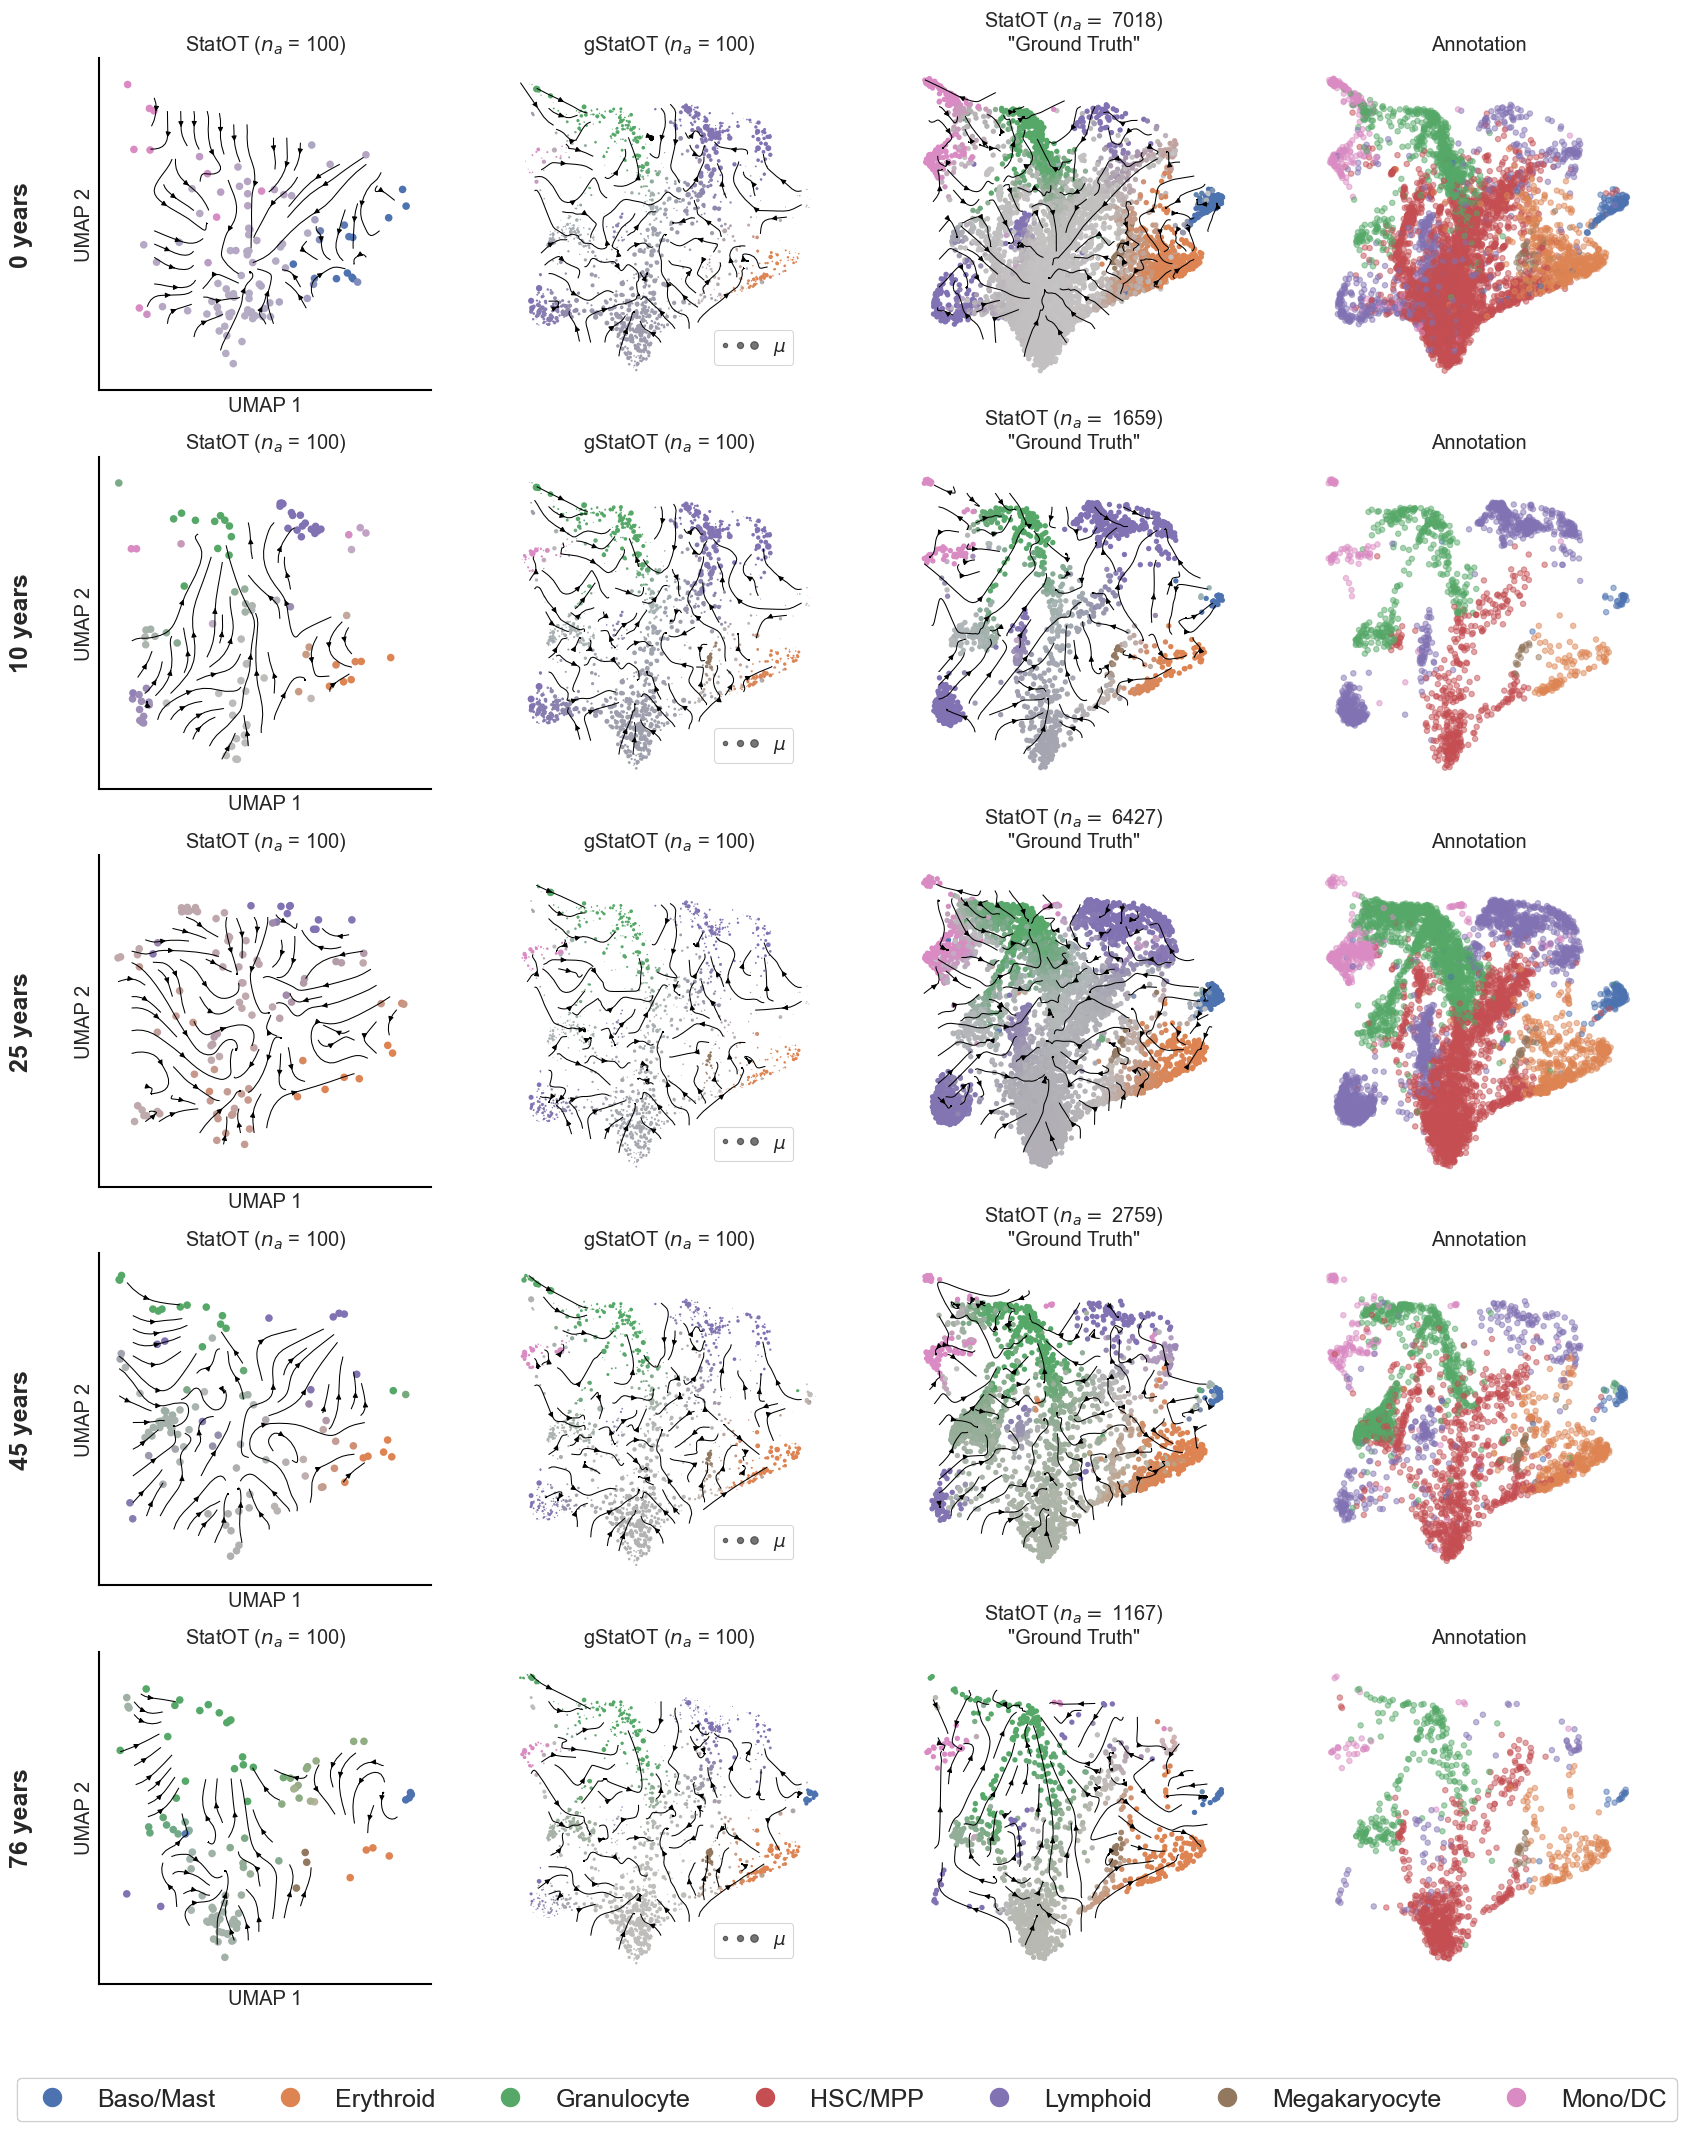

In [10]:
density = 0.75
alpha = 0.2
linewidth = 0.75
show_streams = True

max_s = 30
postnatal_ages = np.unique(postnatal_adata.obs['age_yrs'])[::3]

fig, axes = plt.subplots(len(postnatal_ages), 4, figsize=(20, 5*len(postnatal_ages)), sharex=True, sharey=True)

for ax in axes.flatten():
    ax.set_box_aspect(1)

for i, age in enumerate(postnatal_ages):

    ax1, ax2, ax3, ax4 = axes[i]
    utils.plot_fp(postnatal_downsampled_sot, age=age, time_key='age_yrs', embed_key='X_umap', label_key='cell_type', lineages=postnatal_adata.uns['terminal_lineages'], 
                  lineage_color_map=lin_col_map, full_supp=False, ax=ax1, max_s=max_s, x_lim=x_lim, y_lim=y_lim)
    utils.plot_fp(postnatal_downsampled_gsot, age=age, time_key='age_yrs', embed_key='X_umap', label_key='cell_type', lineages=postnatal_adata.uns['terminal_lineages'], 
                  lineage_color_map=lin_col_map, full_supp=True, ax=ax2, max_s=max_s, x_lim=x_lim, y_lim=y_lim)

    scatter = ax2.collections[0]
    handles, _ = scatter.legend_elements(prop="sizes", num=3, alpha=0.6)
    ax2.legend(
        [tuple(handles)],            
        [r'$\mu$'],      
        handler_map={tuple: HandlerTuple(ndivide=None)}, 
        loc="lower right",
        bbox_to_anchor=(0.9, 0.05)
    )
    utils.plot_fp(postnatal_adata, age=age, time_key='age_yrs', embed_key='X_umap', label_key='cell_type', lineages=postnatal_adata.uns['terminal_lineages'], 
                  lineage_color_map=lin_col_map, full_supp=False, ax=ax3, max_s=max_s/2, x_lim=x_lim, y_lim=y_lim)

    ax4.axis('off')
    X_umap = postnatal_adata.obsm['X_umap'][postnatal_adata.obs['age_yrs'] == age]
    cell_colors = postnatal_adata.obs['cell_type'].map(lin_col_map)[postnatal_adata.obs['age_yrs'] == age]
    ax4.scatter(X_umap[:, 0], X_umap[:, 1], c=cell_colors, s=max_s/2, edgecolor=None, alpha=0.5)
    ax4.set_title("Annotation")
    ax4.set_xlim(x_lim)
    ax4.set_ylim(y_lim)

    handles = [plt.Line2D([0], [0], marker='o', color='w', label=lin, markerfacecolor=col, markersize=5) for lin, col in lin_col_map.items()]
    fig.legend(
        handles=handles,
        loc="lower center", 
        bbox_to_anchor=(0.5, 0.05), 
        markerscale=3,
        ncol=7,
        fontsize=18
    )
    pi = postnatal_downsampled_sot.uns['pi_' + str(age)]
    X_umap = postnatal_downsampled_sot.obsm['X_umap'][postnatal_downsampled_sot.obs['age_yrs'] == age]
    sink_mask = postnatal_downsampled_sot[postnatal_downsampled_sot.obs['age_yrs'] == age].obs['sink'] == 1

    P = utils.row_normalize(jnp.asarray(pi), sink_mask=jnp.asarray(sink_mask))
    vecs = P @ X_umap - X_umap
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True) * pi.sum(0).reshape(-1, 1)

    if show_streams:
        plot_streams(X_umap, vecs, ax1 , density=density, alpha=alpha, linewidth=linewidth)
    
    pi = postnatal_downsampled_gsot.obsp['pi_' + str(age)]
    dist = pi.sum(0)
    P = utils.row_normalize(jnp.asarray(pi), sink_mask=jnp.asarray(postnatal_downsampled_gsot.obs['sink'] == 1))
    X_umap = postnatal_downsampled_gsot.obsm['X_umap']
    vecs = (P @ X_umap - X_umap) 
    vecs = vecs / np.linalg.norm(vecs, axis=1, keepdims=True) * dist.reshape(-1, 1) 
    
    if show_streams:
        plot_streams(X_umap, vecs, ax2, density=density, alpha=alpha, linewidth=linewidth)
    
    pi = postnatal_adata.uns['pi_' + str(age)]
    sink_mask = postnatal_adata[postnatal_adata.obs['age_yrs'] == age].obs['sink'] == 1
    P = utils.row_normalize(jnp.asarray(pi), sink_mask=jnp.asarray(sink_mask))
    X_umap = postnatal_adata.obsm['X_umap'][postnatal_adata.obs['age_yrs'] == age]
    vecs = P @ X_umap - X_umap
    
    if show_streams:
        plot_streams(X_umap, vecs, ax3, density=density, alpha=alpha, linewidth=linewidth)

    ax1.annotate(f'{int(age)} years', 
             xy=(-0.2, 0.5), 
             xycoords='axes fraction',
             fontsize=18, 
             fontweight='bold',
             ha='right',    # Horizontal alignment
             va='center',   # Vertical alignment
             rotation=90)
    
    ax1.set_title(r'StatOT ($n_a$ = {})'.format(100))
    ax2.set_title(r'gStatOT ($n_a$ = {})'.format(100))
    ax3.set_title(r'StatOT ($n_a =$ {})'.format(postnatal_adata[postnatal_adata.obs['age_yrs'] == age].shape[0]) + '\n"Ground Truth"')

    for j in range(3):
        ax = axes[i, j]

        if j == 0:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.spines['left'].set_color('black')
            ax.spines['bottom'].set_color('black')
            ax.spines['left'].set_linewidth(1.5)
            ax.spines['bottom'].set_linewidth(1.5)

            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('left')

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel("UMAP 1")
            ax.set_ylabel("UMAP 2")

        else:
            ax.axis('off')

plt.show()
fig.savefig('./plots/figure_7SI_postnatal_flowfields.png', bbox_inches='tight', dpi=350)